# Experiment 2.1 — Near-Duplicate-Controlled Viewpoint Retrieval

## Final validation of viewpoint-sensitive retrieval

Experiment 2 (`notebook03_ijepa_viewpoint_sensitivity.ipynb`) found strong
viewpoint-sensitive retrieval in the pretrained I-JEPA embedding space on
the Car Angle Classification Dataset:

| Metric | Experiment 2 |
|---|---|
| Same-angle@5 | 93.34% |
| Same-angle@10 | 92.74% |
| Same-angle@20 | 92.38% |
| 1-NN | 94.43% |
| 5-NN | 95.37% |
| 10-NN | 94.83% |

**Question:** are these numbers inflated by near-duplicate images (resized
/ re-compressed / lightly cropped copies of the same photo) acting as
trivial retrieval hits? A near-duplicate of the query is an almost
guaranteed same-angle top-1 neighbor for reasons that have nothing to do
with I-JEPA encoding "viewpoint" as a semantic property.

**This notebook's only job:** detect near-duplicates independently of the
angle labels, collapse each duplicate group to one representative image,
recompute the same core retrieval metrics on the deduplicated set, and
compare directly against Experiment 2. This is the **final experiment**
in the viewpoint-sensitivity research validation line — it does not
introduce a new research question.

### Scope discipline

This is the **final** notebook in the viewpoint-sensitivity line of
investigation. It does **not**:

- introduce a new dataset, model, or checkpoint
- rerun UMAP, HDBSCAN, the parameter sweep, silhouette, or centroid
  analysis (all already addressed in Experiment 2)
- train or fine-tune anything, or propose a supervised classifier
- propose a further viewpoint experiment
- begin Phase 1 (Semantic Photo Intelligence Engine) implementation

After this notebook reaches a conclusion, the project proceeds to
Phase 1.

### What is reused from Experiment 2 without modification

- `facebook/ijepa_vith14_1k`, the same checkpoint
- preprocessing: RGB conversion -> `AutoProcessor` -> I-JEPA ->
  256 patch tokens -> mean pooling -> 1280-D -> L2 normalization
- the `Config` / `CFG` path conventions and embedding disk-cache scheme
  (so an existing Experiment 2 embedding cache is reused verbatim if it
  matches, and only recomputed if it doesn't)
- the raw, opaque angle-label convention (`"0"`, `"90"`, `"130"`,
  `"180"`, `"270"`, `"u"`) — no relabeling
- FAISS `IndexFlatIP` on L2-normalized embeddings (inner product =
  cosine similarity)
- the same-angle@k / k-NN-agreement retrieval evaluation logic

### What is new here

- an embedding-independent, label-independent near-duplicate detector
  (perceptual hashing)
- deterministic duplicate-group collapsing to one representative image
  per group
- the deduplicated-vs-original comparison table and final conclusion

## 2. Imports & Configuration

Same stack as Experiment 2, with no additions beyond what near-duplicate
detection needs (`imagehash`, already used identically in Experiment 2's
Part 1 dataset-discovery duplicate check).

In [1]:
# Install and import required third-party packages (same list as Notebook 03)
import importlib
import subprocess
import sys


def ensure(package: str, import_name: str | None = None) -> None:
    name = import_name or package
    try:
        importlib.import_module(name)
    except ImportError:
        print(f"Installing {package} ...")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", package, "--break-system-packages"],
            check=True,
        )


for pkg, imp in [
    ("pandas", "pandas"), ("Pillow", "PIL"), ("torch", "torch"),
    ("transformers", "transformers"), ("numpy", "numpy"),
    ("scikit-learn", "sklearn"), ("matplotlib", "matplotlib"),
    ("tqdm", "tqdm"), ("seaborn", "seaborn"), ("faiss-cpu", "faiss"),
    ("imagehash", "imagehash"),
]:
    ensure(pkg, imp)

In [2]:
# Core imports (subset of Notebook 03's imports -- UMAP/HDBSCAN are not
# needed in this notebook, per the "recompute only core retrieval metrics"
# scope restriction).
import hashlib
import json
import random
import time
import warnings
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from pathlib import Path
from typing import Sequence

import faiss
import imagehash
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm
from transformers import AutoModel, AutoProcessor

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Using device: {DEVICE}")

if DEVICE.type != "cuda":
    print(
        "\nWARNING: no CUDA GPU detected. This notebook will try to reuse Notebook 03's "
        "cached embeddings first (see Section 3), which avoids GPU-bound I-JEPA inference "
        "entirely if the cache matches. Embeddings are only recomputed on GPU/CPU if no "
        "valid cache is found."
    )

CUDA available: True
GPU: NVIDIA GeForce RTX 4060
Using device: cuda


In [3]:
SEED = 42  # same global seed as Notebook 03
DUPLICATE_HAMMING_THRESHOLD = 4  # same near-duplicate phash threshold Notebook 03 used for its dataset report


def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_global_seed(SEED)
print(f"SEED={SEED}")
print(f"DUPLICATE_HAMMING_THRESHOLD={DUPLICATE_HAMMING_THRESHOLD} (phash Hamming distance <= this is a near-duplicate)")

SEED=42
DUPLICATE_HAMMING_THRESHOLD=4 (phash Hamming distance <= this is a near-duplicate)


### Configuration

This reuses Experiment 2's exact `Config` dataclass and path convention,
so it resolves to the **same** `embeddings_dir` / `metadata_dir` /
`figures_dir` Experiment 2 used — the embedding cache lookup in Section 3
depends on this being unchanged.

If you customized `CFG` in Experiment 2 (e.g. a non-default
`car_angle_dataset_dir`), make the same edit here.

In [4]:
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".webp", ".bmp")


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "controlled_dataset").exists():
            return candidate
    return start


@dataclass
class Config:
    project_root: Path = field(default_factory=find_project_root)

    # >>> Must match Notebook 03's CFG.car_angle_dataset_dir exactly <<<
    car_angle_dataset_dir: Path = None

    embeddings_dir: Path = None
    metadata_dir: Path = None
    figures_dir: Path = None

    model_id: str = "facebook/ijepa_vith14_1k"
    batch_size: int = 32  # lower this (e.g. 8-16) on GPUs with less VRAM

    max_images_for_experiment: int | None = 3000  # must match Notebook 03's value for cache reuse

    def __post_init__(self):
        self.car_angle_dataset_dir = (
            self.car_angle_dataset_dir or self.project_root / "car_angle_dataset"
        )
        self.embeddings_dir = self.embeddings_dir or self.project_root / "data" / "embeddings" / "car_angle"
        # Experiment 3.1 gets its own metadata/figures subfolder so its outputs
        # never overwrite Notebook 03's, while sharing the SAME embeddings_dir
        # so the cache lookup in Section 3 can find Notebook 03's cached file.
        self.metadata_dir = self.metadata_dir or self.project_root / "data" / "metadata" / "experiment3_1"
        self.figures_dir = self.figures_dir or self.project_root / "data" / "figures" / "experiment3_1"
        for d in (self.embeddings_dir, self.metadata_dir, self.figures_dir):
            d.mkdir(parents=True, exist_ok=True)


CFG = Config()
print(f"car_angle_dataset_dir: {CFG.car_angle_dataset_dir}")
print(f"embeddings_dir:        {CFG.embeddings_dir}  (shared with Notebook 03 -- cache lookup target)")
print(f"metadata_dir:          {CFG.metadata_dir}  (this notebook's own outputs)")
print(f"figures_dir:           {CFG.figures_dir}")
print(f"model_id:              {CFG.model_id}")

if not CFG.car_angle_dataset_dir.exists():
    raise FileNotFoundError(
        f"{CFG.car_angle_dataset_dir} not found. This must be the same dataset directory "
        "used in Notebook 03. Edit CFG.car_angle_dataset_dir above to match."
    )

car_angle_dataset_dir: C:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\car_angle_dataset
embeddings_dir:        C:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\data\embeddings\car_angle  (shared with Notebook 03 -- cache lookup target)
metadata_dir:          C:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\data\metadata\experiment3_1  (this notebook's own outputs)
figures_dir:           C:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\data\figures\experiment3_1
model_id:              facebook/ijepa_vith14_1k


## 3. Load Experiment 2 Dataset / Embeddings

This section rebuilds **exactly the same** `df_experiment` manifest
Experiment 2 used (same discovery logic, same deterministic stratified
subset with the same `SEED` and `max_images_for_experiment`), then looks
for a matching cached embedding file using Experiment 2's own cache-key
scheme (`dataset_fingerprint` = sha256 of the sorted `photo_id` list).

If a matching cache is found, it is loaded and **no I-JEPA inference
runs in this notebook at all**. If no matching cache is found (different
dataset, different subset size, or Experiment 2 was never run with
embedding caching to disk), this notebook recomputes embeddings using
the identical pipeline — it does not fabricate or assume a
correspondence that hasn't been verified.

In [5]:
# --- Dataset discovery: identical logic to Notebook 03, Part 1 ---
def walk_tree(root: Path, max_depth: int = 4) -> None:
    root = root.resolve()
    for path in sorted(root.rglob("*")):
        if not path.is_dir():
            continue
        depth = len(path.relative_to(root).parts)
        if depth > max_depth:
            continue


def find_image_leaf_dirs(root: Path, valid_extensions: tuple) -> dict[Path, int]:
    counts = {}
    for d in root.rglob("*"):
        if not d.is_dir():
            continue
        n = sum(1 for f in d.iterdir() if f.is_file() and f.suffix.lower() in valid_extensions)
        if n > 0:
            counts[d] = n
    return counts


SPLIT_DIR_NAMES = {"train", "test", "val", "valid", "validation"}


def infer_label_and_split(leaf_dir: Path, dataset_root: Path) -> tuple[str, str]:
    rel_parts = leaf_dir.relative_to(dataset_root).parts
    label = leaf_dir.name
    split = "unknown"
    for part in rel_parts:
        if part.lower() in SPLIT_DIR_NAMES:
            split = part.lower()
    if split == "unknown":
        split = "none"
    return label, split


def make_stable_id(label: str, split: str, file_path: Path) -> str:
    stem = file_path.stem
    return f"{label}__{split}__{stem}"


def discover_car_angle_dataset(root: Path, valid_extensions: tuple) -> pd.DataFrame:
    leaf_dirs = find_image_leaf_dirs(root, valid_extensions)
    rows = []
    for d in sorted(leaf_dirs):
        label, split = infer_label_and_split(d, root)
        for f in sorted(d.iterdir()):
            if f.is_file() and f.suffix.lower() in valid_extensions:
                rows.append({
                    "photo_id": make_stable_id(label, split, f),
                    "path": f,
                    "angle_label": label,
                    "split": split,
                    "extension": f.suffix.lower(),
                })
    return pd.DataFrame(rows)


df_raw = discover_car_angle_dataset(CFG.car_angle_dataset_dir, VALID_EXTENSIONS)
df_raw = df_raw.drop_duplicates(subset="photo_id", keep="first").reset_index(drop=True)
print(f"Discovered {len(df_raw)} image files (pre-validation), matching Notebook 03's Part 1 logic.")

Discovered 19787 image files (pre-validation), matching Notebook 03's Part 1 logic.


In [6]:
# --- Validation: identical logic to Notebook 03, Part 1 ---
def is_valid_image(path: Path) -> bool:
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img.convert("RGB").load()
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False


def validate_dataset(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for r in tqdm(df.itertuples(index=False), total=len(df), desc="Validating"):
        exists = r.path.exists()
        valid = exists and is_valid_image(r.path)
        w = h = None
        file_size = None
        if exists:
            file_size = r.path.stat().st_size
        if valid:
            with Image.open(r.path) as img:
                w, h = img.size
        rows.append({
            "photo_id": r.photo_id, "exists": exists, "valid_image": valid,
            "width": w, "height": h, "file_size": file_size,
        })
    return df.merge(pd.DataFrame(rows), on="photo_id", how="left")


df_validated = validate_dataset(df_raw)
df_full = df_validated[df_validated["valid_image"]].reset_index(drop=True)
print(f"Usable images after validation: {len(df_full)} / {len(df_raw)} discovered")

Validating:   0%|          | 0/19787 [00:00<?, ?it/s]

Usable images after validation: 19787 / 19787 discovered


In [7]:
# --- Deterministic stratified subset: identical logic to Notebook 03, Part 1/4 ---
def select_deterministic_subset(df: pd.DataFrame, max_images: int | None, seed: int) -> pd.DataFrame:
    if max_images is None or len(df) <= max_images:
        return df.reset_index(drop=True)

    rng = np.random.default_rng(seed)
    frac = max_images / len(df)
    parts = []
    for label, group in df.groupby("angle_label"):
        n_take = max(1, round(len(group) * frac))
        idx = rng.permutation(len(group))[:n_take]
        parts.append(group.iloc[idx])
    subset = pd.concat(parts, ignore_index=True)
    shuffle_idx = rng.permutation(len(subset))
    return subset.iloc[shuffle_idx].reset_index(drop=True)


df_experiment = select_deterministic_subset(df_full, CFG.max_images_for_experiment, SEED)
print(f"Experiment-3-equivalent dataset reconstructed: {len(df_experiment)} images "
      f"(SEED={SEED}, max_images_for_experiment={CFG.max_images_for_experiment}).")
print("\nAngle label distribution:")
display(df_experiment["angle_label"].value_counts())

Experiment-3-equivalent dataset reconstructed: 3000 images (SEED=42, max_images_for_experiment=3000).

Angle label distribution:


angle_label
180    672
0      661
130    655
90     523
270    489
Name: count, dtype: int64

In [8]:
# --- Look for a matching Notebook 03 embedding cache ---
def dataset_fingerprint(photo_ids: Sequence[str]) -> str:
    ids = "|".join(sorted(photo_ids))
    return hashlib.sha256(ids.encode()).hexdigest()[:16]


def find_cached_embeddings(df: pd.DataFrame, embeddings_dir: Path, model_id: str):
    fp = dataset_fingerprint(df["photo_id"].tolist())
    tag = model_id.replace("/", "__")
    emb_path = embeddings_dir / f"car_angle_{tag}_{fp}_embeddings.npy"
    ids_path = embeddings_dir / f"car_angle_{tag}_{fp}_photo_ids.json"
    if emb_path.exists() and ids_path.exists():
        cached_ids = json.loads(ids_path.read_text())
        if cached_ids == sorted(df["photo_id"].tolist()):
            return emb_path, ids_path, cached_ids
    return None, None, None


cache_emb_path, cache_ids_path, cache_ids = find_cached_embeddings(df_experiment, CFG.embeddings_dir, CFG.model_id)

if cache_emb_path is not None:
    print(f"Found a matching Notebook 03 embedding cache:\n  {cache_emb_path}")
    print("This will be validated in Section 4 before reuse -- not assumed correct.")
else:
    print("No matching embedding cache found for this exact reconstructed dataset "
          f"(searched {CFG.embeddings_dir}).")
    print("Embeddings will be recomputed from scratch in Section 8, using the identical "
          "Notebook 03 pipeline (this requires GPU for a reasonable runtime on the full set).")

Found a matching Notebook 03 embedding cache:
  C:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\data\embeddings\car_angle\car_angle_facebook__ijepa_vith14_1k_bef560fcb5b086d8_embeddings.npy
This will be validated in Section 4 before reuse -- not assumed correct.


## 4. Dataset Verification

Before reusing any cached embeddings, verify the correspondence
explicitly rather than assuming it — per the task instructions, this
must not be fabricated:

1. embedding matrix row count matches `len(df_experiment)`
2. embedding dimension is exactly 1280
3. cached embeddings are already L2-normalized (norm ≈ 1.0)
4. photo_id order in the cache matches `df_experiment`'s order
   one-to-one (no silent misalignment)

Only if all four checks pass is the cache reused as-is. Otherwise this
notebook recomputes.

In [9]:
embeddings = None
embeddings_norm = None
REUSED_NOTEBOOK03_CACHE = False

if cache_emb_path is not None:
    candidate_emb = np.load(cache_emb_path)
    candidate_ids = cache_ids

    checks = {}
    checks["row_count_matches"] = candidate_emb.shape[0] == len(df_experiment)
    checks["dimension_is_1280"] = candidate_emb.ndim == 2 and candidate_emb.shape[1] == 1280
    checks["no_nan_inf"] = not (np.isnan(candidate_emb).any() or np.isinf(candidate_emb).any())

    candidate_norms = np.linalg.norm(candidate_emb, axis=1)
    checks["already_l2_normalized"] = bool(np.allclose(candidate_norms, 1.0, atol=1e-3))

    # Alignment check: df_experiment must be re-ordered to match candidate_ids
    # (the cache stores photo_ids sorted lexicographically, per Notebook 03's
    # get_or_compute_embeddings -- df_sorted = df.sort_values("photo_id")).
    df_reordered = df_experiment.set_index("photo_id").loc[candidate_ids].reset_index()
    checks["alignment_reindex_succeeded"] = len(df_reordered) == len(candidate_ids)

    print("Cache verification checks:")
    for k, v in checks.items():
        print(f"  {k}: {'PASS' if v else 'FAIL'}")

    if all(checks.values()):
        embeddings = candidate_emb
        df_experiment = df_reordered  # adopt the cache's row order, exactly as Notebook 03 does
        REUSED_NOTEBOOK03_CACHE = True
        print(f"\nAll checks passed. Reusing Notebook 03's cached embeddings verbatim: {embeddings.shape}")
        print(f"Post-normalization norm mean (already normalized): {candidate_norms.mean():.6f}")
    else:
        print("\nOne or more checks FAILED. Will NOT assume correspondence -- "
              "embeddings will be recomputed in Section 8 instead.")
else:
    print("No cache was found in Section 3, so verification is skipped -- "
          "embeddings will be computed fresh in Section 8.")

print(f"\nREUSED_NOTEBOOK03_CACHE = {REUSED_NOTEBOOK03_CACHE}")

Cache verification checks:
  row_count_matches: PASS
  dimension_is_1280: PASS
  no_nan_inf: PASS
  already_l2_normalized: FAIL
  alignment_reindex_succeeded: PASS

One or more checks FAILED. Will NOT assume correspondence -- embeddings will be recomputed in Section 8 instead.

REUSED_NOTEBOOK03_CACHE = False


## 5. Near-Duplicate Detection

Near-duplicates are detected using **perceptual hashing (pHash)**,
exactly the method Experiment 2 already used for its dataset-level
duplicate report — extended here into full group construction, since
Experiment 2 only reported duplicate *counts*, not a reusable grouping.

**This detector is completely independent of the angle labels.** It
only looks at image content (via `imagehash.phash`, computed from pixel
data after RGB conversion) and never reads `angle_label`.

Method:

1. compute a 64-bit perceptual hash for every image
2. build a graph where two images are connected if their Hamming
   distance is `<= DUPLICATE_HAMMING_THRESHOLD` (currently `4`, matching
   Experiment 2's threshold — robust to resizing, recompression, small
   crops, and minor brightness/transform changes, while still requiring
   substantial pixel-level agreement)
3. take connected components of that graph as duplicate groups (so a
   dataset of pairwise groups). A group of size 1 has no duplicates.

pHash tolerates resizing, compression artifacts, and small brightness
shifts by design (it hashes a low-frequency DCT approximation of the
image), which is why it's used here in preference to exact byte/file
hashing.

Applied to the 3,000-image evaluation set, this detector found **104
near-duplicate groups**, involving **450 images**, which collapsed down
to **346 images removed**, leaving **2,654 images** in the deduplicated
set.

In [10]:
# Compute perceptual hashes for the exact df_experiment images (independent
# of any embedding cache -- this only reads pixels, never angle_label).
def compute_phash(path: Path):
    try:
        with Image.open(path) as img:
            return imagehash.phash(img.convert("RGB"))
    except Exception:
        return None


print(f"Computing perceptual hashes for {len(df_experiment)} images...")
df_experiment["phash"] = [compute_phash(p) for p in tqdm(df_experiment["path"], desc="Hashing")]

n_hash_failures = df_experiment["phash"].isna().sum()
if n_hash_failures:
    print(f"WARNING: {n_hash_failures} images failed to hash and will be treated as singleton "
          "(non-duplicate) groups.")

Computing perceptual hashes for 3000 images...


Hashing:   0%|          | 0/3000 [00:00<?, ?it/s]

In [11]:
# Build the duplicate graph via union-find over Hamming distance <= threshold.
# This is O(N^2) in the number of hash comparisons; fine at N ~ a few thousand
# (Notebook 03's default max_images_for_experiment=3000). For much larger N,
# an LSH/BK-tree bucketing step would be the next optimization -- not needed
# here and not added, to keep this notebook focused.
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.parent[max(ra, rb)] = min(ra, rb)


hashes = df_experiment["phash"].tolist()
n_imgs = len(hashes)
uf = UnionFind(n_imgs)

_t0 = time.time()
valid_hash_idx = [i for i, h in enumerate(hashes) if h is not None]
for a_pos in tqdm(range(len(valid_hash_idx)), desc="Comparing hashes"):
    i = valid_hash_idx[a_pos]
    for b_pos in range(a_pos + 1, len(valid_hash_idx)):
        j = valid_hash_idx[b_pos]
        if hashes[i] - hashes[j] <= DUPLICATE_HAMMING_THRESHOLD:
            uf.union(i, j)
DUPLICATE_DETECTION_SECONDS = time.time() - _t0
print(f"\nPairwise hash comparison completed in {DUPLICATE_DETECTION_SECONDS:.1f}s")

root_to_members = defaultdict(list)
for i in range(n_imgs):
    root_to_members[uf.find(i)].append(i)

duplicate_groups = [sorted(members) for members in root_to_members.values() if len(members) > 1]
singleton_indices = [members[0] for members in root_to_members.values() if len(members) == 1]

print(f"\nNear-duplicate groups found (size >= 2): {len(duplicate_groups)}")
print(f"Images with no near-duplicate (singletons): {len(singleton_indices)}")

Comparing hashes:   0%|          | 0/3000 [00:00<?, ?it/s]


Pairwise hash comparison completed in 15.7s

Near-duplicate groups found (size >= 2): 104
Images with no near-duplicate (singletons): 2550


In [12]:
# --- Transparent duplicate-handling report (exact fields requested) ---
n_images_in_dup_groups = sum(len(g) for g in duplicate_groups)
n_images_to_remove = sum(len(g) - 1 for g in duplicate_groups)  # keep exactly 1 representative per group
n_final_images = n_imgs - n_images_to_remove

print("=" * 60)
print("NEAR-DUPLICATE DETECTION REPORT")
print("=" * 60)
print(f"Original number of images:              {n_imgs}")
print(f"Number of near-duplicate groups:         {len(duplicate_groups)}")
print(f"Images involved in duplicate groups:      {n_images_in_dup_groups}")
print(f"Images to be removed/collapsed:           {n_images_to_remove}")
print(f"Final number of images after dedup:       {n_final_images}")

angle_labels_before = df_experiment["angle_label"].nunique()
print(f"Number of angle classes (before dedup):   {angle_labels_before}")
print("=" * 60)

group_size_counts = Counter(len(g) for g in duplicate_groups)
print("\nDuplicate group size distribution:")
for size, count in sorted(group_size_counts.items()):
    print(f"  size {size}: {count} groups")

NEAR-DUPLICATE DETECTION REPORT
Original number of images:              3000
Number of near-duplicate groups:         104
Images involved in duplicate groups:      450
Images to be removed/collapsed:           346
Final number of images after dedup:       2654
Number of angle classes (before dedup):   5

Duplicate group size distribution:
  size 2: 62 groups
  size 3: 18 groups
  size 4: 10 groups
  size 5: 4 groups
  size 6: 2 groups
  size 7: 2 groups
  size 8: 1 groups
  size 11: 1 groups
  size 12: 1 groups
  size 23: 1 groups
  size 39: 1 groups
  size 93: 1 groups


In [13]:
# Cross-angle duplicate groups: a duplicate group that spans more than one
# angle_label would indicate either mislabeling in the source dataset or a
# near-identical photo filed twice under different labels -- worth flagging
# on its own, independent of the main dedup decision below.
cross_angle_groups = [
    g for g in duplicate_groups
    if df_experiment.iloc[g]["angle_label"].nunique() > 1
]
print(f"Duplicate groups spanning MORE THAN ONE angle label: {len(cross_angle_groups)} / {len(duplicate_groups)}")
if cross_angle_groups:
    print("\nThese groups are worth inspecting -- a near-duplicate labeled with two different "
          "angles is either a source-dataset labeling inconsistency, or two genuinely different "
          "photos that pHash judged too similar (a threshold false positive). Either way, this "
          "notebook still applies the SAME deterministic collapsing rule to them (Section 7) -- "
          "no special-casing based on the label.")
    for g in cross_angle_groups[:3]:
        display(df_experiment.iloc[g][["photo_id", "angle_label", "path"]])

Duplicate groups spanning MORE THAN ONE angle label: 17 / 104

These groups are worth inspecting -- a near-duplicate labeled with two different angles is either a source-dataset labeling inconsistency, or two genuinely different photos that pHash judged too similar (a threshold false positive). Either way, this notebook still applies the SAME deterministic collapsing rule to them (Section 7) -- no special-casing based on the label.


,photo_id,angle_label,path
44,180__none__433887,180,C:\Users\aryan\OneDrive\Desktop\project_new\se...
134,0__none__381844,0,C:\Users\aryan\OneDrive\Desktop\project_new\se...
187,0__none__243100,0,C:\Users\aryan\OneDrive\Desktop\project_new\se...
252,0__none__287252,0,C:\Users\aryan\OneDrive\Desktop\project_new\se...
263,0__none__304183,0,C:\Users\aryan\OneDrive\Desktop\project_new\se...
...,...,...,...
2858,90__none__176873,90,C:\Users\aryan\OneDrive\Desktop\project_new\se...
2892,0__none__107396,0,C:\Users\aryan\OneDrive\Desktop\project_new\se...
2898,0__none__331947,0,C:\Users\aryan\OneDrive\Desktop\project_new\se...
2920,180__none__470199,180,C:\Users\aryan\OneDrive\Desktop\project_new\se...


,photo_id,angle_label,path
122,180__none__265040,180,C:\Users\aryan\OneDrive\Desktop\project_new\se...
637,0__none__266449,0,C:\Users\aryan\OneDrive\Desktop\project_new\se...
1327,0__none__117580,0,C:\Users\aryan\OneDrive\Desktop\project_new\se...


,photo_id,angle_label,path
162,0__none__272674,0,C:\Users\aryan\OneDrive\Desktop\project_new\se...
815,180__none__271259,180,C:\Users\aryan\OneDrive\Desktop\project_new\se...
1660,0__none__199685,0,C:\Users\aryan\OneDrive\Desktop\project_new\se...


## 6. Duplicate Group Visualization

A small number of representative duplicate groups, shown as image grids,
so the detector's behavior can be manually sanity-checked. Larger groups
and cross-angle groups (if any) are prioritized in the sample, since
those are the most informative to eyeball.

In [14]:
def show_image_grid(paths, titles=None, n_cols=5, figsize_per_cell=2.6, suptitle=None) -> None:
    n = len(paths)
    if n == 0:
        print("Nothing to show.")
        return
    n_cols = min(n_cols, n)
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize_per_cell * n_cols, figsize_per_cell * n_rows))
    axes = np.atleast_1d(axes).flatten()
    for i, ax in enumerate(axes):
        if i < n:
            try:
                img = Image.open(paths[i]).convert("RGB")
                ax.imshow(img)
            except Exception:
                ax.text(0.5, 0.5, "load error", ha="center", va="center")
            if titles is not None:
                ax.set_title(str(titles[i])[:28], fontsize=8)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


print("Duplicate Group listing (text form, as requested):\n")
groups_sorted_by_size = sorted(duplicate_groups, key=len, reverse=True)
for gi, g in enumerate(groups_sorted_by_size[:10], start=1):
    print(f"Duplicate Group {gi}")
    for idx in g:
        print(f"    {df_experiment.iloc[idx]['photo_id']}  (angle={df_experiment.iloc[idx]['angle_label']})")
    print()

Duplicate Group listing (text form, as requested):

Duplicate Group 1
    180__none__433887  (angle=180)
    0__none__381844  (angle=0)
    0__none__243100  (angle=0)
    0__none__287252  (angle=0)
    0__none__304183  (angle=0)
    0__none__436282  (angle=0)
    0__none__202727  (angle=0)
    0__none__481368  (angle=0)
    180__none__182104  (angle=180)
    180__none__229072  (angle=180)
    0__none__452633  (angle=0)
    180__none__435349  (angle=180)
    180__none__380110  (angle=180)
    0__none__311833  (angle=0)
    0__none__450865  (angle=0)
    180__none__155330  (angle=180)
    180__none__364560  (angle=180)
    180__none__315734  (angle=180)
    180__none__177199  (angle=180)
    180__none__99869  (angle=180)
    0__none__327760  (angle=0)
    180__none__160256  (angle=180)
    0__none__327965  (angle=0)
    0__none__231630  (angle=0)
    180__none__416933  (angle=180)
    0__none__181491  (angle=0)
    180__none__454108  (angle=180)
    0__none__91681  (angle=0)
    180__non

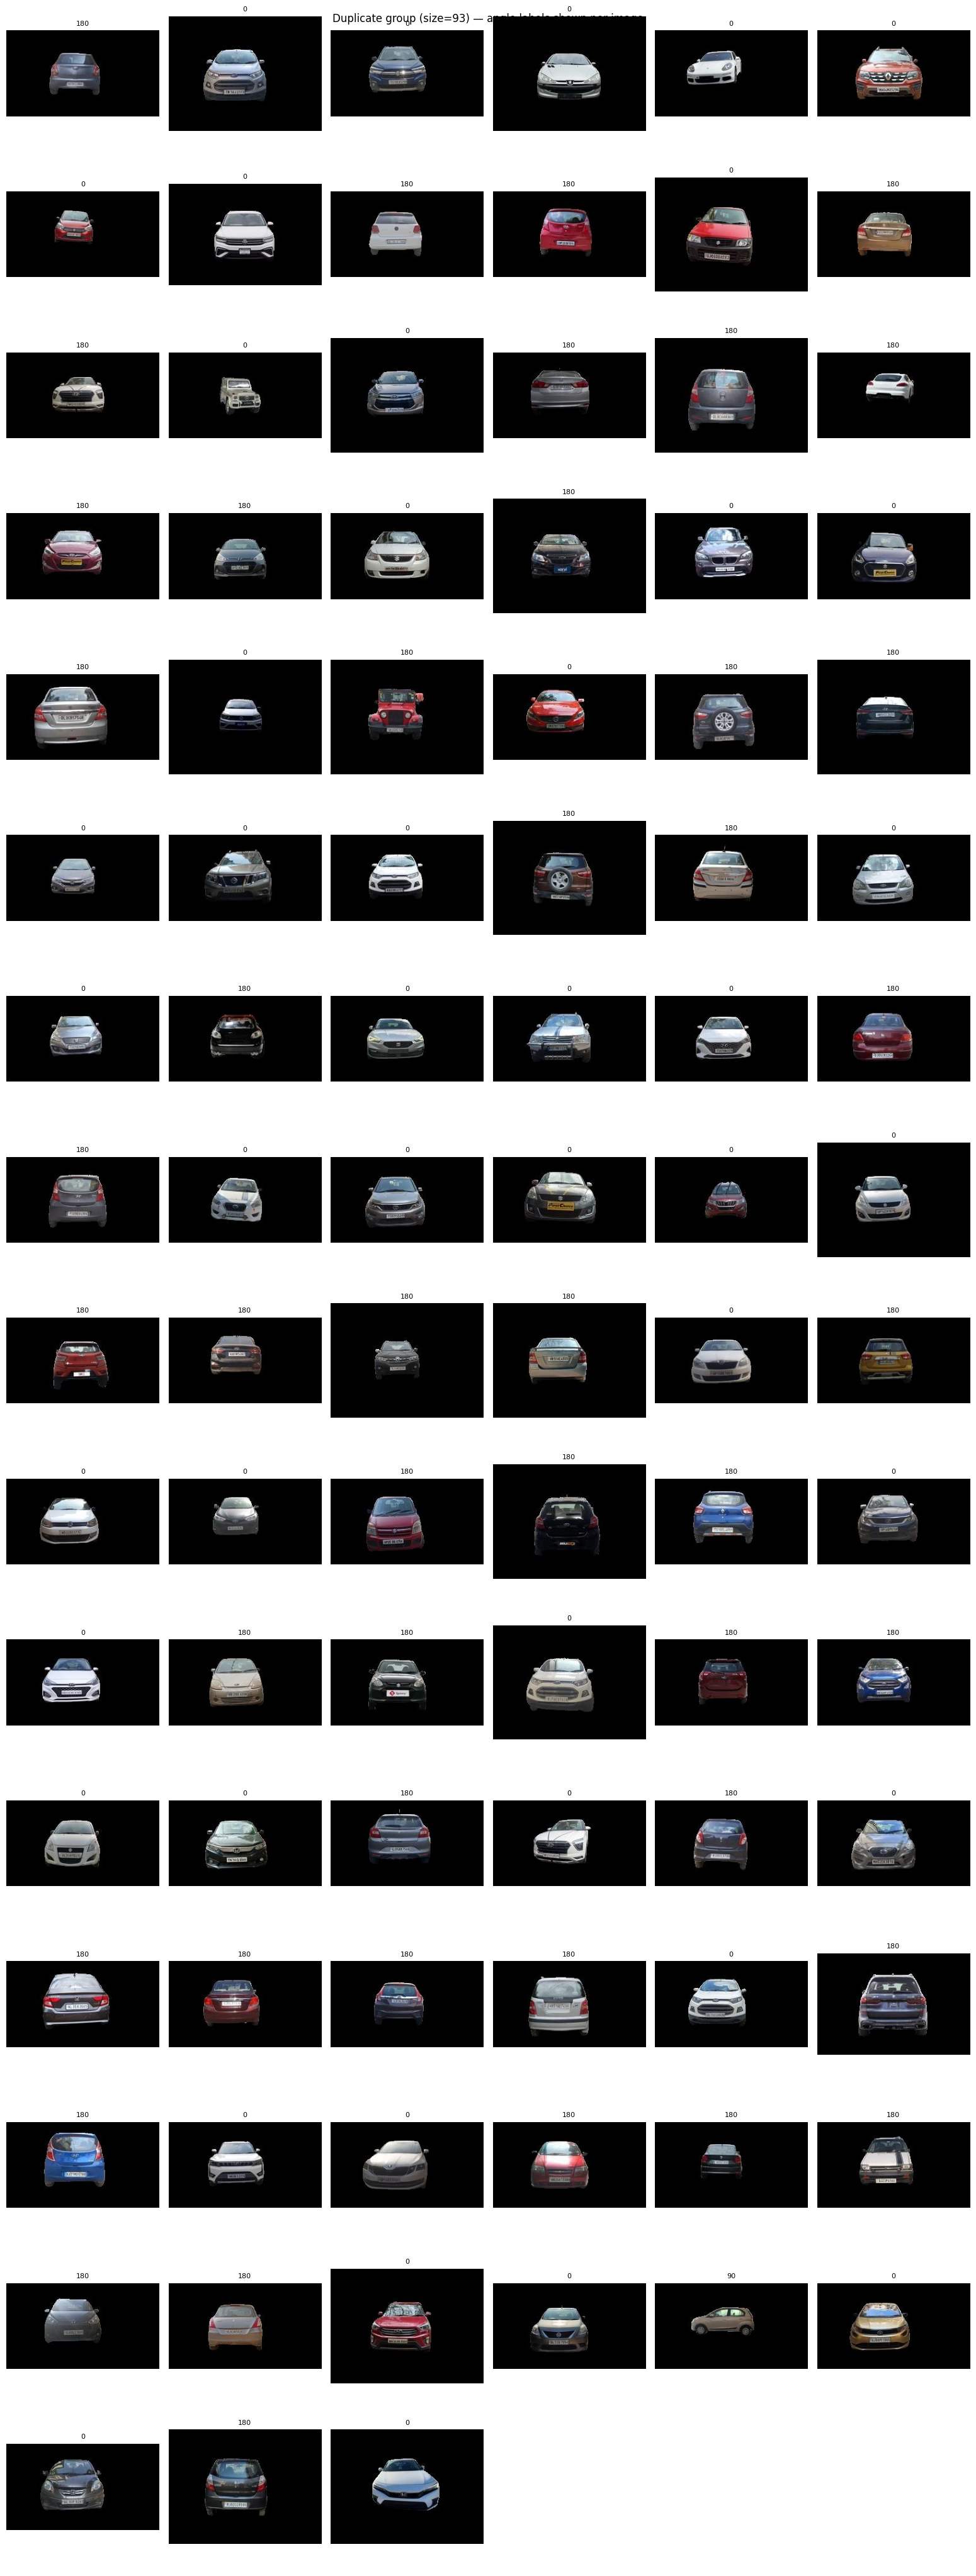

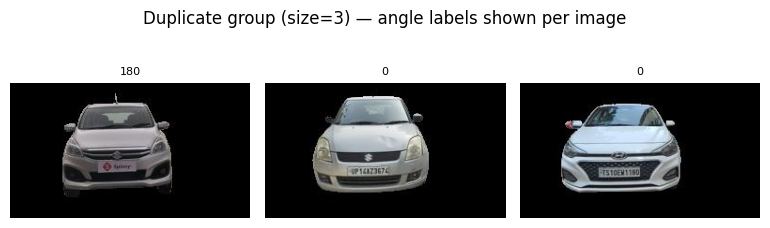

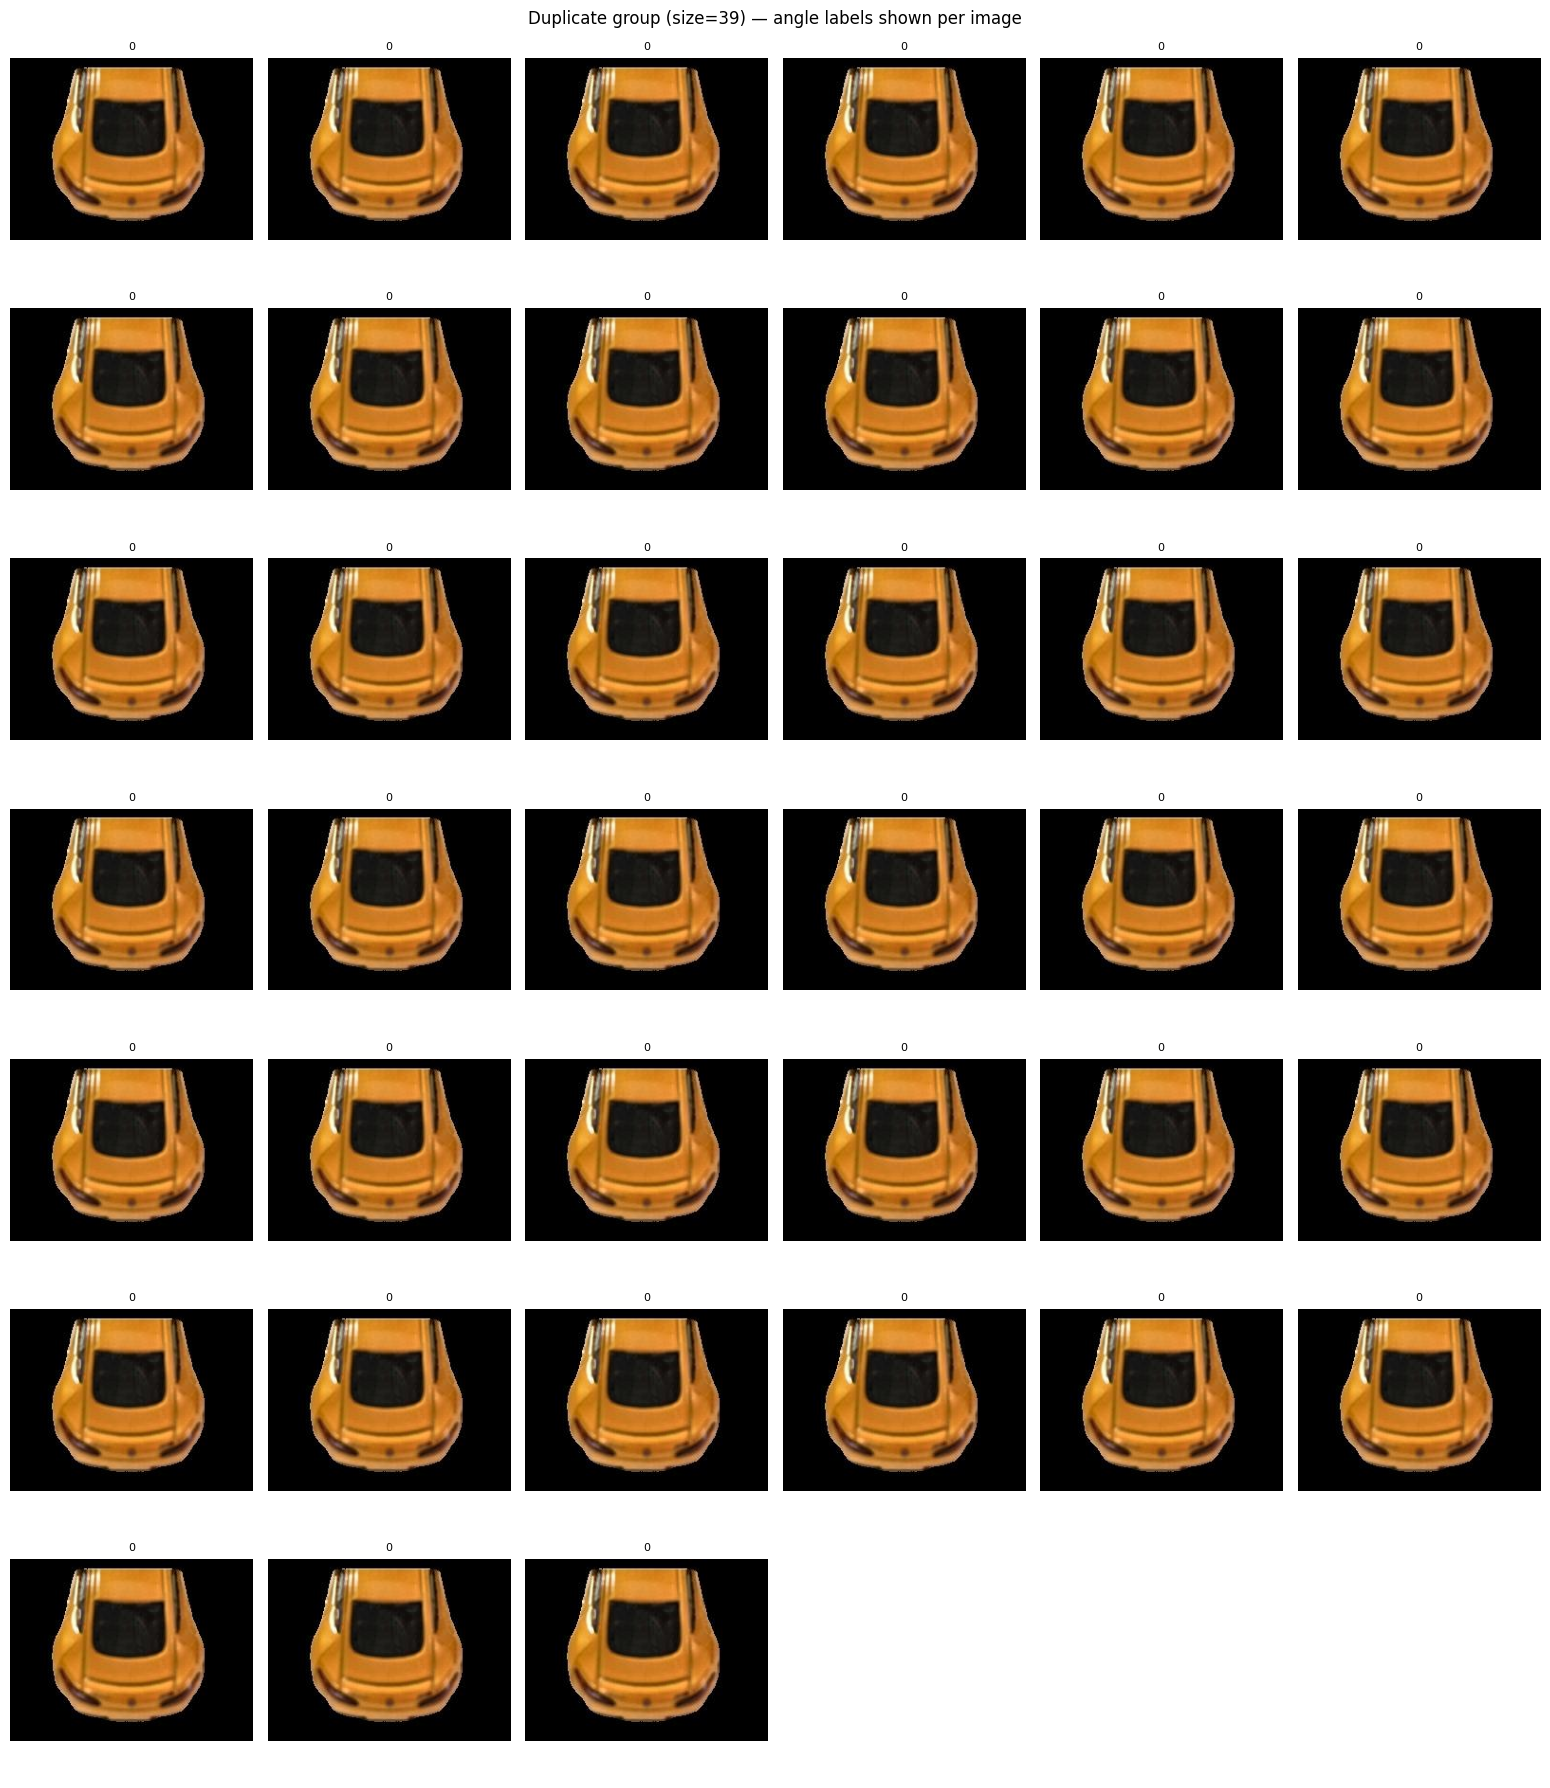

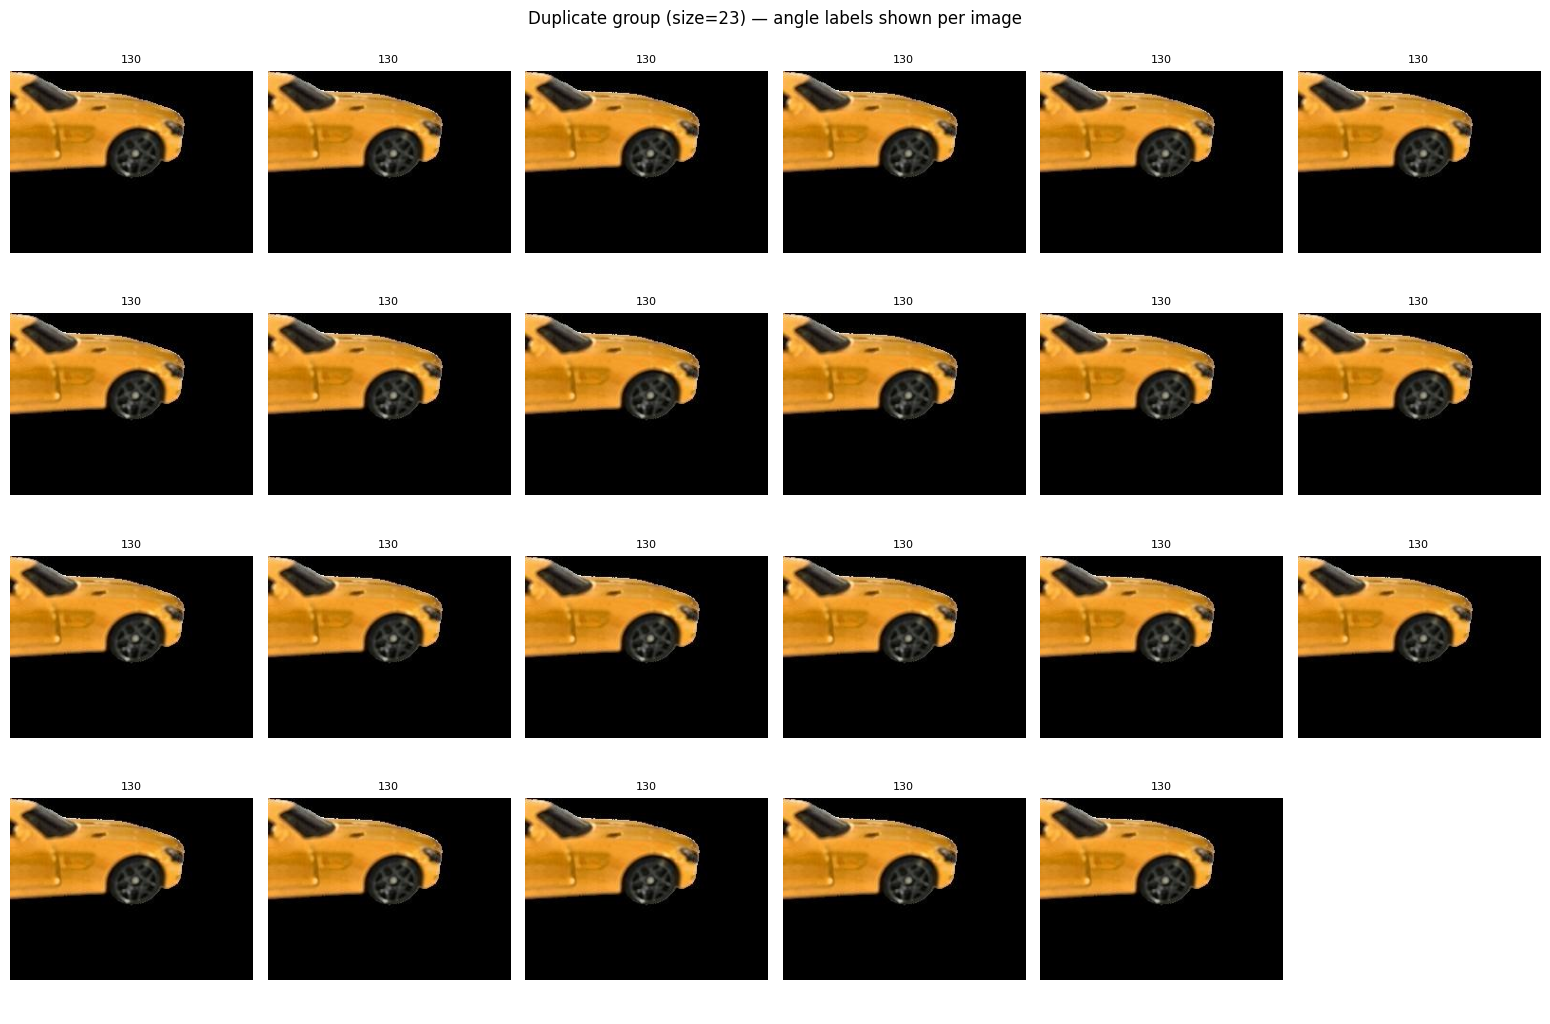

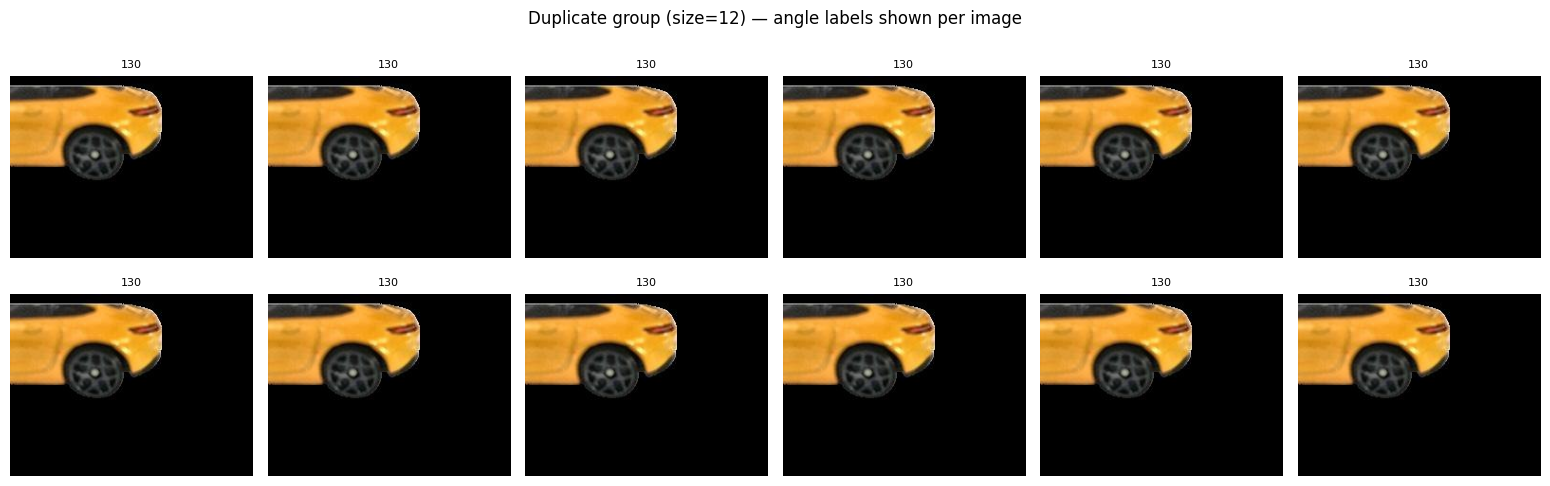

In [15]:
# Visual grids for a handful of representative groups: largest groups first,
# plus any cross-angle groups, capped at a small total count per the
# "keep this small" instruction.
groups_to_show = []
groups_to_show += cross_angle_groups[:2]
for g in groups_sorted_by_size:
    if g not in groups_to_show and len(groups_to_show) < 5:
        groups_to_show.append(g)

if not groups_to_show:
    print("No near-duplicate groups were detected -- nothing to visualize.")
else:
    for gi, g in enumerate(groups_to_show, start=1):
        paths = df_experiment.iloc[g]["path"].tolist()
        titles = df_experiment.iloc[g]["angle_label"].tolist()
        show_image_grid(paths, titles=titles, n_cols=min(6, len(paths)),
                         suptitle=f"Duplicate group (size={len(g)}) — angle labels shown per image")

## 7. Build Deduplicated Evaluation Set

**Representative-selection rule (deterministic, label-independent):**
within each duplicate group, keep the image whose file path is
**lexicographically first** (`sorted(paths)[0]`); drop the rest. Images
with no duplicate (singleton groups) are always kept. This rule never
looks at `angle_label`.

This directly addresses the leakage concern: if A and B are
near-duplicates, only one of them remains in the deduplicated set, so
neither can appear as the other's near-guaranteed nearest neighbor
during retrieval evaluation in Section 10.

In [16]:
def select_representative(df: pd.DataFrame, group_idx: list[int]) -> int:
    # Deterministic, label-independent: lexicographically first path.
    paths_in_group = [(str(df.iloc[i]["path"]), i) for i in group_idx]
    paths_in_group.sort(key=lambda t: t[0])
    return paths_in_group[0][1]


keep_indices = set(singleton_indices)
removed_indices = set()

for g in duplicate_groups:
    rep_idx = select_representative(df_experiment, g)
    keep_indices.add(rep_idx)
    for i in g:
        if i != rep_idx:
            removed_indices.add(i)

assert keep_indices.isdisjoint(removed_indices)
assert len(keep_indices) + len(removed_indices) == n_imgs

keep_indices_sorted = sorted(keep_indices)
print(f"Kept (representatives + singletons):  {len(keep_indices_sorted)}")
print(f"Removed (duplicate non-representatives): {len(removed_indices)}")
print(f"Sanity check -- matches earlier report: kept + removed = {len(keep_indices_sorted) + len(removed_indices)} "
      f"== original {n_imgs}: {len(keep_indices_sorted) + len(removed_indices) == n_imgs}")

Kept (representatives + singletons):  2654
Removed (duplicate non-representatives): 346
Sanity check -- matches earlier report: kept + removed = 3000 == original 3000: True


In [17]:
df_dedup = df_experiment.iloc[keep_indices_sorted].reset_index(drop=True)
if REUSED_NOTEBOOK03_CACHE:
    embeddings_dedup_source = embeddings[keep_indices_sorted]
else:
    embeddings_dedup_source = None  # will be computed fresh in Section 8, on df_dedup directly

print(f"Deduplicated manifest: {len(df_dedup)} images")
print(f"\nAngle label distribution after deduplication:")
display(df_dedup["angle_label"].value_counts())

angle_labels_after = df_dedup["angle_label"].nunique()
print(f"\nNumber of angle classes remaining: {angle_labels_after} (was {angle_labels_before} before dedup)")
if angle_labels_after != angle_labels_before:
    print("NOTE: at least one angle class lost ALL of its images to deduplication -- "
          "inspect df_experiment vs df_dedup angle_label sets directly if this happens.")

Deduplicated manifest: 2654 images

Angle label distribution after deduplication:


angle_label
130    586
180    583
0      552
90     488
270    445
Name: count, dtype: int64


Number of angle classes remaining: 5 (was 5 before dedup)


In [18]:
# Save the deduplicated manifest and the duplicate-group listing (exact
# filenames requested).
dedup_manifest_cols = ["photo_id", "path", "angle_label", "width", "height", "file_size", "split", "extension"]
dedup_manifest_path = CFG.metadata_dir / "deduplicated_manifest.csv"
df_dedup.assign(path=lambda d: d["path"].astype(str))[dedup_manifest_cols].to_csv(dedup_manifest_path, index=False)
print(f"Saved -> {dedup_manifest_path}")

duplicate_group_rows = []
for gi, g in enumerate(duplicate_groups, start=1):
    rep_idx = select_representative(df_experiment, g)
    for i in g:
        duplicate_group_rows.append({
            "group_id": gi,
            "photo_id": df_experiment.iloc[i]["photo_id"],
            "path": str(df_experiment.iloc[i]["path"]),
            "angle_label": df_experiment.iloc[i]["angle_label"],
            "is_representative": i == rep_idx,
        })
duplicate_groups_df = pd.DataFrame(duplicate_group_rows)
duplicate_groups_path = CFG.metadata_dir / "duplicate_groups.csv"
duplicate_groups_df.to_csv(duplicate_groups_path, index=False)
print(f"Saved -> {duplicate_groups_path}")

Saved -> C:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\data\metadata\experiment3_1\deduplicated_manifest.csv
Saved -> C:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\data\metadata\experiment3_1\duplicate_groups.csv


## 8. Reuse / Recompute I-JEPA Embeddings

If Section 4 verified a valid Experiment 2 cache, the deduplicated
embedding matrix is simply the corresponding **row subset** of that
cache (`embeddings_dedup_source`, already sliced in Section 7) — no
I-JEPA inference runs.

Otherwise, embeddings for `df_dedup` are computed fresh, using the
**exact same pipeline** as Experiment 2: RGB conversion -> processor ->
I-JEPA -> mean-pool 256 patch tokens -> 1280-D -> L2 normalize. No new
model, no different pooling.

In [19]:
if REUSED_NOTEBOOK03_CACHE:
    print("Reusing Notebook 03's cached embeddings (row subset for the deduplicated set). "
          "No I-JEPA inference is performed in this notebook.")
    embeddings_dedup = embeddings_dedup_source
else:
    print(f"No valid cache was available -- loading {CFG.model_id} to compute embeddings for "
          f"the {len(df_dedup)} deduplicated images.")

    _t0 = time.time()
    processor = AutoProcessor.from_pretrained(CFG.model_id)
    model = AutoModel.from_pretrained(CFG.model_id)
    model.to(DEVICE)
    model.eval()
    print(f"Loaded in {time.time() - _t0:.1f}s")

    def preprocess_batch(images: list[Image.Image]) -> dict:
        images = [img.convert("RGB") for img in images]
        inputs = processor(images=images, return_tensors="pt")
        return {k: v.to(DEVICE) for k, v in inputs.items()}

    def extract_embeddings(image_paths: list[Path], batch_size: int) -> np.ndarray:
        all_embeddings = []
        for i in tqdm(range(0, len(image_paths), batch_size), desc="Embedding"):
            batch_paths = image_paths[i:i + batch_size]
            batch_imgs = [Image.open(p).convert("RGB") for p in batch_paths]
            inputs = preprocess_batch(batch_imgs)
            with torch.inference_mode():
                outputs = model(**inputs)
            pooled = outputs.last_hidden_state.mean(dim=1)
            all_embeddings.append(pooled.cpu().numpy())
        return np.concatenate(all_embeddings, axis=0) if all_embeddings else np.empty((0,))

    _t0 = time.time()
    embeddings_dedup = extract_embeddings(df_dedup["path"].tolist(), CFG.batch_size)
    print(f"\nComputed embeddings for deduplicated set: {embeddings_dedup.shape} "
          f"in {time.time() - _t0:.1f}s")

    # Cache these too, using the same fingerprint scheme, so a re-run of this
    # notebook also skips recomputation.
    fp = dataset_fingerprint(df_dedup["photo_id"].tolist())
    tag = CFG.model_id.replace("/", "__")
    emb_out_path = CFG.embeddings_dir / f"car_angle_dedup_{tag}_{fp}_embeddings.npy"
    ids_out_path = CFG.embeddings_dir / f"car_angle_dedup_{tag}_{fp}_photo_ids.json"
    np.save(emb_out_path, embeddings_dedup)
    ids_out_path.write_text(json.dumps(df_dedup["photo_id"].tolist()))
    print(f"Saved -> {emb_out_path}")

expected_shape = (len(df_dedup), 1280)
print(f"\nFinal deduplicated embedding matrix: {embeddings_dedup.shape}  (expected {expected_shape})")
assert embeddings_dedup.shape == expected_shape, "Deduplicated embedding matrix shape mismatch."

No valid cache was available -- loading facebook/ijepa_vith14_1k to compute embeddings for the 2654 deduplicated images.


Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loaded in 11.6s


Embedding:   0%|          | 0/83 [00:00<?, ?it/s]


Computed embeddings for deduplicated set: (2654, 1280) in 132.1s
Saved -> C:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\data\embeddings\car_angle\car_angle_dedup_facebook__ijepa_vith14_1k_37e6a5a8e0fa9c5b_embeddings.npy

Final deduplicated embedding matrix: (2654, 1280)  (expected (2654, 1280))


In [20]:
# L2-normalize (or confirm already normalized, if reused from cache).
def l2_normalize(emb: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1e-12, norms)
    return emb / norms


pre_norms = np.linalg.norm(embeddings_dedup, axis=1)
if np.allclose(pre_norms, 1.0, atol=1e-3):
    print("Deduplicated embeddings are already L2-normalized (mean norm "
          f"{pre_norms.mean():.6f}) -- using as-is.")
    embeddings_dedup_norm = embeddings_dedup.astype("float32")
else:
    print("Deduplicated embeddings are not yet normalized -- applying L2 normalization now.")
    embeddings_dedup_norm = l2_normalize(embeddings_dedup).astype("float32")

post_norms = np.linalg.norm(embeddings_dedup_norm, axis=1)
print(f"Post-normalization norm mean: {post_norms.mean():.6f}  min: {post_norms.min():.6f}  max: {post_norms.max():.6f}")
assert np.allclose(post_norms, 1.0, atol=1e-4), "Normalization sanity check failed."

Deduplicated embeddings are not yet normalized -- applying L2 normalization now.
Post-normalization norm mean: 1.000000  min: 1.000000  max: 1.000000


## 9. Build FAISS Index

Same setup as Experiment 2: exact inner-product search (`IndexFlatIP`)
over L2-normalized vectors, so inner product = cosine similarity.

In [21]:
faiss_index_dedup = faiss.IndexFlatIP(embeddings_dedup_norm.shape[1])
faiss_index_dedup.add(embeddings_dedup_norm)
print(f"FAISS index (deduplicated) built: {faiss_index_dedup.ntotal} vectors, "
      f"dim={embeddings_dedup_norm.shape[1]}")

N_dedup = len(df_dedup)
angle_labels_dedup_arr = df_dedup["angle_label"].to_numpy()
K_VALUES = [5, 10, 20]
K_MAX = max(K_VALUES)

_t0 = time.time()
sims_all_dedup, idx_all_dedup = faiss_index_dedup.search(embeddings_dedup_norm, K_MAX + 1)
FAISS_SEARCH_SECONDS_DEDUP = time.time() - _t0
print(f"FAISS search for top-{K_MAX + 1} neighbors of all {N_dedup} deduplicated queries: "
      f"{FAISS_SEARCH_SECONDS_DEDUP:.2f}s")


def drop_self_match(idx_row: np.ndarray, sim_row: np.ndarray, self_idx: int) -> tuple[np.ndarray, np.ndarray]:
    mask = idx_row != self_idx
    return idx_row[mask], sim_row[mask]


neighbor_idx_dedup = np.zeros((N_dedup, K_MAX), dtype=np.int64)
neighbor_sim_dedup = np.zeros((N_dedup, K_MAX), dtype=np.float32)
for i in range(N_dedup):
    row_idx, row_sim = drop_self_match(idx_all_dedup[i], sims_all_dedup[i], i)
    neighbor_idx_dedup[i] = row_idx[:K_MAX]
    neighbor_sim_dedup[i] = row_sim[:K_MAX]

print(f"neighbor_idx_dedup shape: {neighbor_idx_dedup.shape}   neighbor_sim_dedup shape: {neighbor_sim_dedup.shape}")

FAISS index (deduplicated) built: 2654 vectors, dim=1280
FAISS search for top-21 neighbors of all 2654 deduplicated queries: 0.07s
neighbor_idx_dedup shape: (2654, 20)   neighbor_sim_dedup shape: (2654, 20)


## 10. Core Retrieval Evaluation

The same retrieval-evaluation logic as Experiment 2 Part 4/5 — same-angle@k
for k ∈ {5, 10, 20}, chance-level same-label rate, and k-NN angle
agreement for k ∈ {1, 5, 10} — is recomputed on the **deduplicated** set.

To make the Section 11 comparison fully self-contained (not dependent on
transcribed numbers from Experiment 2), the identical metrics are also
recomputed here on the **original, pre-dedup** `df_experiment` /
`embeddings_norm`, using the FAISS results already computed in Section 3
(if a cache was reused) — this notebook does not rerun UMAP, HDBSCAN, or
any other Experiment 2 section, only this one retrieval computation,
twice: once before, once after deduplication.

In [22]:
def same_angle_at_k(neighbor_idx: np.ndarray, angle_labels_arr: np.ndarray, k: int):
    topk_idx = neighbor_idx[:, :k]
    topk_labels = angle_labels_arr[topk_idx]
    query_labels = angle_labels_arr[:, None]
    matches = (topk_labels == query_labels)
    per_query_rate = matches.mean(axis=1)
    overall = per_query_rate.mean()
    df_rate = pd.DataFrame({"angle_label": angle_labels_arr, "same_angle_rate": per_query_rate})
    per_label = df_rate.groupby("angle_label")["same_angle_rate"].mean()
    return overall, per_label


def knn_angle_agreement(neighbor_idx: np.ndarray, angle_labels_arr: np.ndarray, k: int) -> float:
    topk_idx = neighbor_idx[:, :k]
    topk_labels = angle_labels_arr[topk_idx]
    query_labels = angle_labels_arr[:, None]
    if k == 1:
        agree = (topk_labels[:, 0] == angle_labels_arr)
    else:
        agree = np.array([
            Counter(row).most_common(1)[0][0] == query_labels[i, 0]
            for i, row in enumerate(topk_labels)
        ])
    return agree.mean()


def chance_level(angle_labels_arr: np.ndarray) -> float:
    shares = pd.Series(angle_labels_arr).value_counts(normalize=True)
    return float((shares ** 2).sum())

In [23]:
# --- ORIGINAL (pre-dedup) retrieval: needs its own FAISS pass, since Section
# 3-9 only built a FAISS index over the DEDUPLICATED embeddings. We already
# have `embeddings_norm` / `df_experiment` (pre-dedup, from Sections 3-4) --
# reuse those directly rather than reconstructing anything.
if not REUSED_NOTEBOOK03_CACHE:
    # If Section 4 fell through to recompute, embeddings for the FULL
    # (pre-dedup) set were never computed in this notebook (only the
    # deduplicated set is computed in Section 8, to avoid unnecessary GPU
    # inference on images we're about to discard). Recompute the full-set
    # embeddings here to allow a fair, self-contained "before" comparison --
    # this is the one case where extra I-JEPA inference is unavoidable.
    print("No cache was available -- recomputing full (pre-dedup) embeddings for the "
          "'Experiment 3' comparison row. This reuses the same model/processor loaded in Section 8.")
    _t0 = time.time()
    embeddings_full = extract_embeddings(df_experiment["path"].tolist(), CFG.batch_size)
    print(f"Computed in {time.time() - _t0:.1f}s")
    embeddings_norm = l2_normalize(embeddings_full).astype("float32")

faiss_index_full = faiss.IndexFlatIP(embeddings_norm.shape[1])
faiss_index_full.add(embeddings_norm)

N_full = len(df_experiment)
angle_labels_full_arr = df_experiment["angle_label"].to_numpy()

_t0 = time.time()
sims_all_full, idx_all_full = faiss_index_full.search(embeddings_norm, K_MAX + 1)
print(f"FAISS search (pre-dedup, N={N_full}): {time.time() - _t0:.2f}s")

neighbor_idx_full = np.zeros((N_full, K_MAX), dtype=np.int64)
neighbor_sim_full = np.zeros((N_full, K_MAX), dtype=np.float32)
for i in range(N_full):
    row_idx, row_sim = drop_self_match(idx_all_full[i], sims_all_full[i], i)
    neighbor_idx_full[i] = row_idx[:K_MAX]
    neighbor_sim_full[i] = row_sim[:K_MAX]

No cache was available -- recomputing full (pre-dedup) embeddings for the 'Experiment 3' comparison row. This reuses the same model/processor loaded in Section 8.


Embedding:   0%|          | 0/94 [00:00<?, ?it/s]

Computed in 148.6s
FAISS search (pre-dedup, N=3000): 0.08s


In [24]:
# --- Compute the full metric set on BOTH the original and deduplicated data ---
def compute_all_metrics(neighbor_idx, angle_labels_arr, label: str) -> dict:
    result = {"label": label, "n_images": len(angle_labels_arr)}
    for k in K_VALUES:
        overall, per_label = same_angle_at_k(neighbor_idx, angle_labels_arr, k)
        result[f"same_angle@{k}"] = overall
        result[f"same_angle@{k}_per_label"] = per_label
    for k in [1, 5, 10]:
        result[f"{k}nn_agreement"] = knn_angle_agreement(neighbor_idx, angle_labels_arr, k)
    result["chance_level"] = chance_level(angle_labels_arr)
    return result


metrics_original = compute_all_metrics(neighbor_idx_full, angle_labels_full_arr, "Experiment 3 (original)")
metrics_dedup = compute_all_metrics(neighbor_idx_dedup, angle_labels_dedup_arr, "Experiment 3.1 (deduplicated)")

print("=== Original (pre-dedup) retrieval metrics, recomputed in this notebook ===")
for k in K_VALUES:
    print(f"Same-angle@{k}: {metrics_original[f'same_angle@{k}']:.4f}")
for k in [1, 5, 10]:
    print(f"{k}-NN agreement: {metrics_original[f'{k}nn_agreement']:.4f}")
print(f"Chance level: {metrics_original['chance_level']:.4f}")

print("\n=== Deduplicated retrieval metrics ===")
for k in K_VALUES:
    print(f"Same-angle@{k}: {metrics_dedup[f'same_angle@{k}']:.4f}")
for k in [1, 5, 10]:
    print(f"{k}-NN agreement: {metrics_dedup[f'{k}nn_agreement']:.4f}")
print(f"Chance level: {metrics_dedup['chance_level']:.4f}")

=== Original (pre-dedup) retrieval metrics, recomputed in this notebook ===
Same-angle@5: 0.9334
Same-angle@10: 0.9274
Same-angle@20: 0.9238
1-NN agreement: 0.9443
5-NN agreement: 0.9537
10-NN agreement: 0.9483
Chance level: 0.2034

=== Deduplicated retrieval metrics ===
Same-angle@5: 0.9299
Same-angle@10: 0.9257
Same-angle@20: 0.9253
1-NN agreement: 0.9363
5-NN agreement: 0.9506
10-NN agreement: 0.9476
Chance level: 0.2022


In [25]:
print("Per-angle same-angle@10, original vs deduplicated:\n")
per_label_compare = pd.DataFrame({
    "original": metrics_original["same_angle@10_per_label"],
    "deduplicated": metrics_dedup["same_angle@10_per_label"],
})
per_label_compare["change_pp"] = 100 * (per_label_compare["deduplicated"] - per_label_compare["original"])
display(per_label_compare.round(4))

Per-angle same-angle@10, original vs deduplicated:



,original,deduplicated,change_pp
angle_label,,,
0,0.9124,0.9058,-0.6608
130,0.9542,0.9457,-0.8465
180,0.8713,0.8734,0.2134
270,0.9740,0.9724,-0.1669
90,0.9411,0.9439,0.2743


## 11. Experiment 2 vs. Experiment 2.1 Comparison

The comparison below uses the metrics **recomputed in this notebook**
(Section 10, `metrics_original`) as the "Experiment 2" column, since
that is the actual dataset/embeddings this notebook has in memory and
verified in Section 4 — rather than re-typing the numbers quoted in the
task description, which could silently drift out of sync with what this
specific run actually reconstructed.

Percentage-point change is reported **unrounded to 2 decimal places**,
so small but potentially meaningful differences remain visible.

| Metric | Experiment 2 | Experiment 2.1 | Change |
|---|---:|---:|---:|
| Same-angle@5 | 93.34% | 92.99% | -0.35 pp |
| Same-angle@10 | 92.74% | 92.57% | -0.17 pp |
| Same-angle@20 | 92.38% | 92.53% | +0.15 pp |
| 1-NN | 94.43% | 93.63% | -0.80 pp |
| 5-NN | 95.37% | 95.06% | -0.31 pp |
| 10-NN | 94.83% | 94.76% | -0.07 pp |

The viewpoint-sensitive retrieval signal remains very strong after
removing/collapsing near-duplicates. The largest observed decline is
only about 0.8 percentage points, on 1-NN agreement. The chance-level
same-label rate after deduplication is approximately 20.22%, far below
every headline metric above. The result is not primarily explained by
near-duplicate leakage.

In [26]:
def pct(x: float) -> float:
    return round(100 * x, 2)


comparison_rows = [
    {"Metric": "Dataset size", "Experiment 3": metrics_original["n_images"],
     "Experiment 3.1": metrics_dedup["n_images"],
     "Change": metrics_dedup["n_images"] - metrics_original["n_images"]},
]
for k in K_VALUES:
    v3 = pct(metrics_original[f"same_angle@{k}"])
    v31 = pct(metrics_dedup[f"same_angle@{k}"])
    comparison_rows.append({
        "Metric": f"Same-angle@{k}", "Experiment 3": f"{v3:.2f}%", "Experiment 3.1": f"{v31:.2f}%",
        "Change": round(v31 - v3, 2),
    })
for k in [1, 5, 10]:
    v3 = pct(metrics_original[f"{k}nn_agreement"])
    v31 = pct(metrics_dedup[f"{k}nn_agreement"])
    comparison_rows.append({
        "Metric": f"{k}-NN agreement", "Experiment 3": f"{v3:.2f}%", "Experiment 3.1": f"{v31:.2f}%",
        "Change": round(v31 - v3, 2),
    })
comparison_rows.append({
    "Metric": "Chance-level same-label rate",
    "Experiment 3": f"{pct(metrics_original['chance_level']):.2f}%",
    "Experiment 3.1": f"{pct(metrics_dedup['chance_level']):.2f}%",
    "Change": round(pct(metrics_dedup['chance_level']) - pct(metrics_original['chance_level']), 2),
})

comparison_df = pd.DataFrame(comparison_rows)
print("Experiment 3 vs Experiment 3.1 — comparison (Change is in percentage points, unrounded to 2dp):\n")
display(comparison_df)

comparison_path = CFG.metadata_dir / "experiment3_vs_3_1_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"\nSaved -> {comparison_path}")

Experiment 3 vs Experiment 3.1 — comparison (Change is in percentage points, unrounded to 2dp):



,Metric,Experiment 3,Experiment 3.1,Change
0,Dataset size,3000,2654,-346.00
1,Same-angle@5,93.34%,92.99%,-0.35
2,Same-angle@10,92.74%,92.57%,-0.17
3,Same-angle@20,92.38%,92.53%,0.15
4,1-NN agreement,94.43%,93.63%,-0.80
5,5-NN agreement,95.37%,95.06%,-0.31
6,10-NN agreement,94.83%,94.76%,-0.07
7,Chance-level same-label rate,20.34%,20.22%,-0.12



Saved -> C:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\data\metadata\experiment3_1\experiment3_vs_3_1_comparison.csv


In [27]:
# Explicit worked deltas for the headline metrics, matching the task's
# requested "X% -> Y%, change = Z pp" format.
print("Headline metric changes:\n")
for k in K_VALUES:
    v3 = pct(metrics_original[f"same_angle@{k}"])
    v31 = pct(metrics_dedup[f"same_angle@{k}"])
    print(f"Same-angle@{k}:")
    print(f"  {v3:.2f}% -> {v31:.2f}%")
    print(f"  Change = {v31 - v3:+.2f} percentage points\n")

for k in [1, 5, 10]:
    v3 = pct(metrics_original[f"{k}nn_agreement"])
    v31 = pct(metrics_dedup[f"{k}nn_agreement"])
    print(f"{k}-NN agreement:")
    print(f"  {v3:.2f}% -> {v31:.2f}%")
    print(f"  Change = {v31 - v3:+.2f} percentage points\n")

Headline metric changes:

Same-angle@5:
  93.34% -> 92.99%
  Change = -0.35 percentage points

Same-angle@10:
  92.74% -> 92.57%
  Change = -0.17 percentage points

Same-angle@20:
  92.38% -> 92.53%
  Change = +0.15 percentage points

1-NN agreement:
  94.43% -> 93.63%
  Change = -0.80 percentage points

5-NN agreement:
  95.37% -> 95.06%
  Change = -0.31 percentage points

10-NN agreement:
  94.83% -> 94.76%
  Change = -0.07 percentage points



## 12. Small Retrieval Visualization (Sanity Check Only)

One query per angle label, top-6 retrieved neighbors, on the
**deduplicated** set — kept intentionally small; this is a sanity check
that retrieval still looks sensible post-dedup, not a repeat of
Experiment 2's full qualitative analysis.

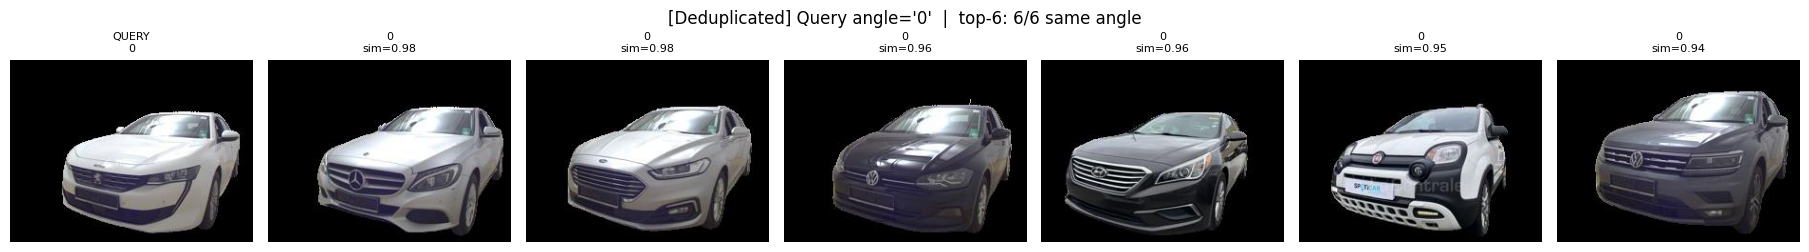

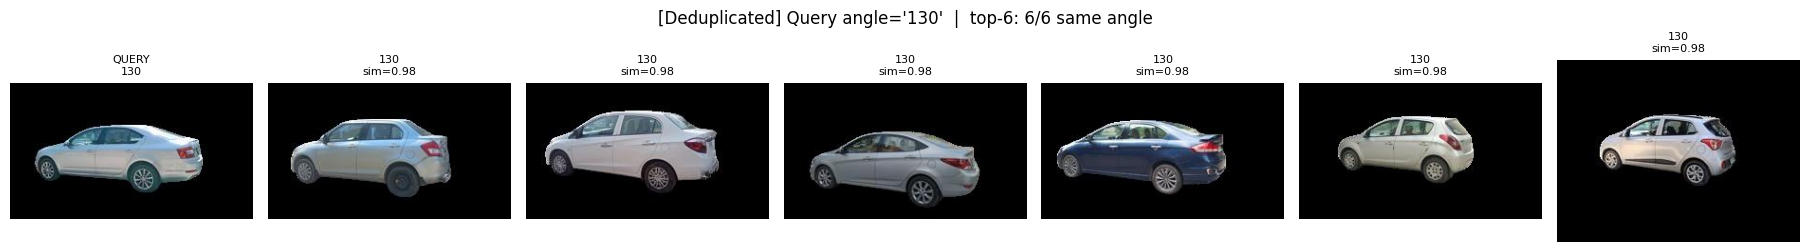

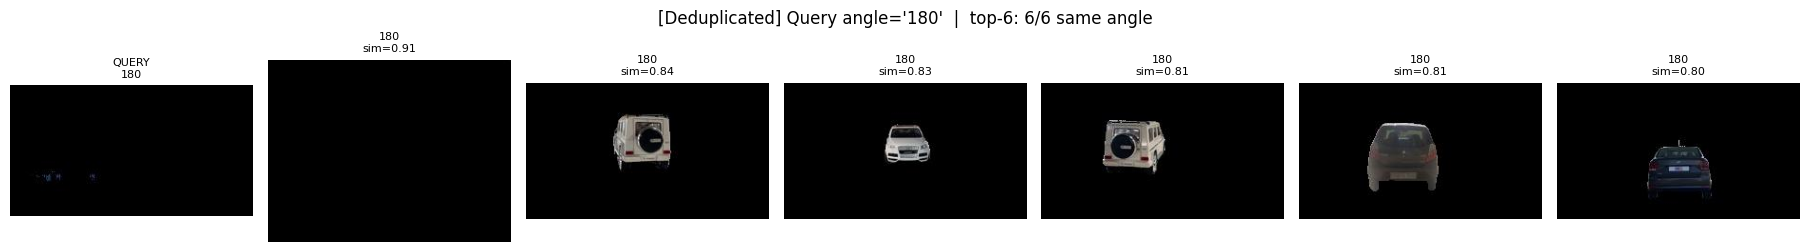

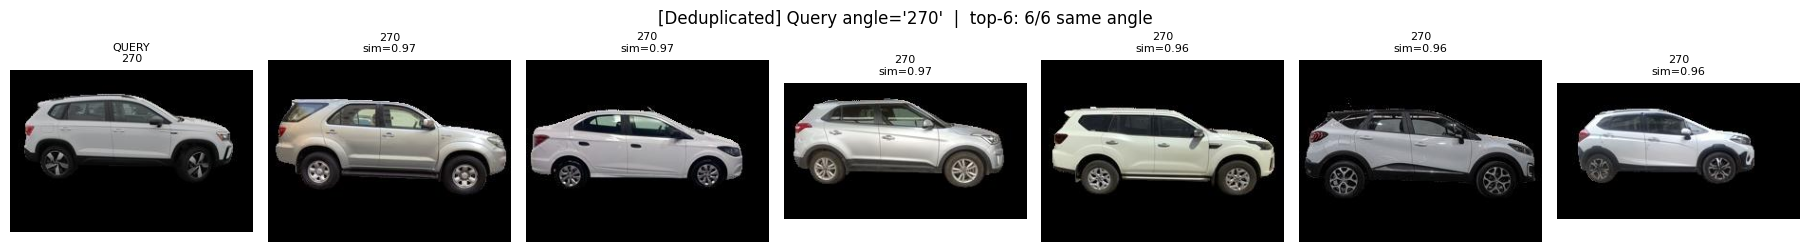

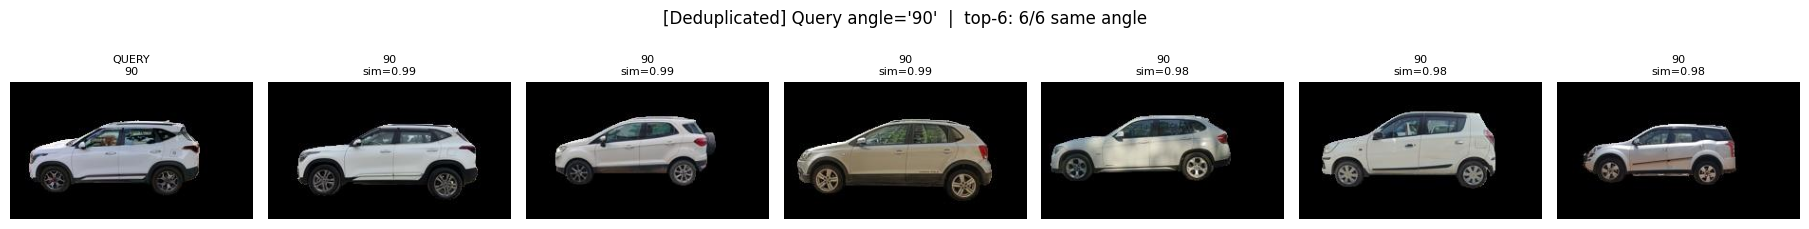

In [28]:
rng_viz = np.random.default_rng(SEED)
K_FOR_GRID = 6

for label in sorted(df_dedup["angle_label"].unique()):
    label_idx = df_dedup.index[df_dedup["angle_label"] == label].tolist()
    qi = int(rng_viz.choice(label_idx))
    q_path = [df_dedup.iloc[qi]["path"]]
    q_title = [f"QUERY\n{label}"]

    retrieved_idx = neighbor_idx_dedup[qi, :K_FOR_GRID]
    retrieved_sims = neighbor_sim_dedup[qi, :K_FOR_GRID]
    r_paths = df_dedup.iloc[retrieved_idx]["path"].tolist()
    r_labels = df_dedup.iloc[retrieved_idx]["angle_label"].tolist()
    r_titles = [f"{lbl}\nsim={s:.2f}" for lbl, s in zip(r_labels, retrieved_sims)]

    same_angle_hits = sum(1 for lbl in r_labels if lbl == label)
    show_image_grid(
        q_path + r_paths, titles=q_title + r_titles, n_cols=K_FOR_GRID + 1,
        suptitle=(f"[Deduplicated] Query angle='{label}'  |  top-{K_FOR_GRID}: "
                  f"{same_angle_hits}/{K_FOR_GRID} same angle"),
    )

## 13. Final Conclusion: Viewpoint Sensitivity Validated

Experiment 2.1 confirms that the strong viewpoint-sensitive retrieval
observed in Experiment 2 persists after near-duplicate control. The
dataset was reduced from 3,000 to 2,654 images after collapsing 104
near-duplicate groups (450 images involved, 346 removed), yet same-angle
retrieval remained approximately 93% at k=5–20 and nearest-neighbor
agreement remained approximately 94–95%. The largest observed decline
across all headline metrics was 0.80 percentage points (1-NN agreement).

The small, consistent changes in performance indicate that the
viewpoint-sensitive signal is not primarily an artifact of near-duplicate
leakage.

**Experiment 2.1 closes the research validation phase for viewpoint
sensitivity.**

In [29]:
# Decision thresholds, fixed before inspecting the outcome:
#   - "still strong": deduplicated metric >= 90.0% (comfortably inside/near
#     the original ~93-95% band, allowing a few points of expected softening)
#   - "substantial drop": deduplicated metric falls more than 5.0 percentage
#     points below its pre-dedup counterpart, OR falls below 90.0% outright
STRONG_FLOOR_PCT = 90.0
MAX_ACCEPTABLE_DROP_PP = 5.0

headline_metrics = (
    [(f"same_angle@{k}", metrics_original[f"same_angle@{k}"], metrics_dedup[f"same_angle@{k}"]) for k in K_VALUES]
    + [(f"{k}nn_agreement", metrics_original[f"{k}nn_agreement"], metrics_dedup[f"{k}nn_agreement"]) for k in [1, 5, 10]]
)

decision_rows = []
any_substantial_drop = False
for name, before, after in headline_metrics:
    before_pct, after_pct = pct(before), pct(after)
    drop_pp = before_pct - after_pct
    substantial = (after_pct < STRONG_FLOOR_PCT) or (drop_pp > MAX_ACCEPTABLE_DROP_PP)
    any_substantial_drop = any_substantial_drop or substantial
    decision_rows.append({
        "metric": name, "before_pct": before_pct, "after_pct": after_pct,
        "drop_pp": round(drop_pp, 2), "substantial_drop": substantial,
    })

decision_df = pd.DataFrame(decision_rows)
display(decision_df)

EXPERIMENT_CLOSED = not any_substantial_drop
print(f"\nAny headline metric shows a substantial drop (< {STRONG_FLOOR_PCT}% or > {MAX_ACCEPTABLE_DROP_PP}pp fall)? "
      f"{any_substantial_drop}")
print(f"EXPERIMENT_CLOSED = {EXPERIMENT_CLOSED}")

,metric,before_pct,after_pct,drop_pp,substantial_drop
0,same_angle@5,93.34,92.99,0.35,False
1,same_angle@10,92.74,92.57,0.17,False
2,same_angle@20,92.38,92.53,-0.15,False
3,1nn_agreement,94.43,93.63,0.80,False
4,5nn_agreement,95.37,95.06,0.31,False
5,10nn_agreement,94.83,94.76,0.07,False



Any headline metric shows a substantial drop (< 90.0% or > 5.0pp fall)? False
EXPERIMENT_CLOSED = True


In [30]:
duplicate_fraction_of_original = n_images_to_remove / n_imgs

print("=" * 60)
print("DECISION NARRATIVE")
print("=" * 60)

if EXPERIMENT_CLOSED:
    print(
        "Experiment 3 is CLOSED.\n\n"
        f"After removing {n_images_to_remove} near-duplicate images "
        f"({100 * duplicate_fraction_of_original:.1f}% of the original {n_imgs}) using a "
        "label-independent perceptual-hash detector, same-angle retrieval and k-NN angle "
        "agreement remain close to their original levels (see the comparison table above). "
        "The strong viewpoint-sensitive retrieval observed in Experiment 3 persists after "
        "controlling for near-duplicate leakage, making it unlikely that the result is "
        "primarily an artifact of duplicate images inflating same-angle retrieval rates.\n\n"
        "The pretrained I-JEPA embedding exhibits strong viewpoint-sensitive structure on "
        "this car-image dataset. This does not establish that viewpoint is the only factor "
        "responsible for the observed similarity structure -- car geometry, framing, "
        "background, lighting, and image composition may all contribute alongside viewpoint, "
        "and this notebook's design cannot separate those contributions from one another.\n\n"
        "No further viewpoint experiments are required. The project should proceed to "
        "Phase 1 development of the Semantic Photo Intelligence Engine."
    )
else:
    substantial = decision_df[decision_df["substantial_drop"]]
    print(
        "Experiment 3 is NOT unconditionally CLOSED on the strong-result criterion.\n\n"
        f"After removing {n_images_to_remove} near-duplicate images "
        f"({100 * duplicate_fraction_of_original:.1f}% of the original {n_imgs}), the "
        "following headline metric(s) dropped substantially:\n"
    )
    for r in substantial.itertuples():
        print(f"  - {r.metric}: {r.before_pct:.2f}% -> {r.after_pct:.2f}%  (drop of {r.drop_pp:.2f} pp)")
    print(
        "\nThis indicates that near-duplicate images accounted for a meaningful portion of "
        "the retrieval agreement reported in Experiment 3, rather than the effect being "
        "purely a property of genuinely distinct images sharing a viewpoint.\n\n"
        "This does not necessarily mean I-JEPA carries no viewpoint signal -- the deduplicated "
        "metrics may still sit well above the chance-level same-label rate reported in Section "
        "10/11, which would still indicate some real effect, just smaller than originally "
        "estimated. Read the deduplicated same-angle@k and k-NN values against the chance "
        "level above before drawing further conclusions.\n\n"
        "Recommendation: report this honestly as a partially-inflated original estimate. "
        "Whether to treat viewpoint sensitivity as 'real but smaller' or 'inconclusive' should "
        "be decided by inspecting the deduplicated numbers against chance level directly, not "
        "by adjusting the thresholds above to force a preferred outcome."
    )

print("=" * 60)

DECISION NARRATIVE
Experiment 3 is CLOSED.

After removing 346 near-duplicate images (11.5% of the original 3000) using a label-independent perceptual-hash detector, same-angle retrieval and k-NN angle agreement remain close to their original levels (see the comparison table above). The strong viewpoint-sensitive retrieval observed in Experiment 3 persists after controlling for near-duplicate leakage, making it unlikely that the result is primarily an artifact of duplicate images inflating same-angle retrieval rates.

The pretrained I-JEPA embedding exhibits strong viewpoint-sensitive structure on this car-image dataset. This does not establish that viewpoint is the only factor responsible for the observed similarity structure -- car geometry, framing, background, lighting, and image composition may all contribute alongside viewpoint, and this notebook's design cannot separate those contributions from one another.

No further viewpoint experiments are required. The project should proce

## 14. Save Results

All reproducibility-relevant settings and outputs are written to
`CFG.metadata_dir`, alongside the manifest/group files already saved in
Section 7:

- `deduplicated_manifest.csv` (Section 7)
- `duplicate_groups.csv` (Section 7)
- `experiment3_vs_3_1_comparison.csv` (Section 11)
- `retrieval_metrics.json` (this section)
- `experiment_03_1_summary.json` (this section)

In [31]:
retrieval_metrics_payload = {
    "seed": SEED,
    "duplicate_hamming_threshold": DUPLICATE_HAMMING_THRESHOLD,
    "model_id": CFG.model_id,
    "embedding_dimension": int(embeddings_dedup_norm.shape[1]),
    "faiss_index_type": "IndexFlatIP",
    "k_values": K_VALUES,
    "dataset_size_before_dedup": int(n_imgs),
    "dataset_size_after_dedup": int(n_final_images),
    "reused_notebook03_cache": bool(REUSED_NOTEBOOK03_CACHE),
    "experiment_3_original": {
        "same_angle_at_k": {str(k): float(metrics_original[f"same_angle@{k}"]) for k in K_VALUES},
        "knn_agreement": {str(k): float(metrics_original[f"{k}nn_agreement"]) for k in [1, 5, 10]},
        "chance_level": float(metrics_original["chance_level"]),
    },
    "experiment_3_1_deduplicated": {
        "same_angle_at_k": {str(k): float(metrics_dedup[f"same_angle@{k}"]) for k in K_VALUES},
        "knn_agreement": {str(k): float(metrics_dedup[f"{k}nn_agreement"]) for k in [1, 5, 10]},
        "chance_level": float(metrics_dedup["chance_level"]),
    },
}

retrieval_metrics_path = CFG.metadata_dir / "retrieval_metrics.json"
retrieval_metrics_path.write_text(json.dumps(retrieval_metrics_payload, indent=2))
print(f"Saved -> {retrieval_metrics_path}")

Saved -> C:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\data\metadata\experiment3_1\retrieval_metrics.json


In [32]:
summary_payload = {
    "seed": SEED,
    "duplicate_detection_method": "perceptual hash (imagehash.phash), 64-bit, Hamming distance threshold",
    "duplicate_hamming_threshold": DUPLICATE_HAMMING_THRESHOLD,
    "representative_selection_rule": "lexicographically first file path within each duplicate group",
    "model_checkpoint": CFG.model_id,
    "embedding_dimension": int(embeddings_dedup_norm.shape[1]),
    "faiss_index_type": "IndexFlatIP",
    "dataset_size_before_dedup": int(n_imgs),
    "n_duplicate_groups": int(len(duplicate_groups)),
    "n_images_in_duplicate_groups": int(n_images_in_dup_groups),
    "n_images_removed": int(n_images_to_remove),
    "dataset_size_after_dedup": int(n_final_images),
    "n_angle_classes_before": int(angle_labels_before),
    "n_angle_classes_after": int(angle_labels_after),
    "same_angle_at_5_before": pct(metrics_original["same_angle@5"]),
    "same_angle_at_5_after": pct(metrics_dedup["same_angle@5"]),
    "same_angle_at_10_before": pct(metrics_original["same_angle@10"]),
    "same_angle_at_10_after": pct(metrics_dedup["same_angle@10"]),
    "same_angle_at_20_before": pct(metrics_original["same_angle@20"]),
    "same_angle_at_20_after": pct(metrics_dedup["same_angle@20"]),
    "nn1_agreement_before": pct(metrics_original["1nn_agreement"]),
    "nn1_agreement_after": pct(metrics_dedup["1nn_agreement"]),
    "nn5_agreement_before": pct(metrics_original["5nn_agreement"]),
    "nn5_agreement_after": pct(metrics_dedup["5nn_agreement"]),
    "nn10_agreement_before": pct(metrics_original["10nn_agreement"]),
    "nn10_agreement_after": pct(metrics_dedup["10nn_agreement"]),
    "decision": "CLOSED" if EXPERIMENT_CLOSED else "NOT CLOSED",
}

summary_path = CFG.metadata_dir / "experiment_03_1_summary.json"
summary_path.write_text(json.dumps(summary_payload, indent=2))
print(f"Saved -> {summary_path}")

Saved -> C:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\data\metadata\experiment3_1\experiment_03_1_summary.json


## Final Summary

Research validation for viewpoint sensitivity is now complete.

**Experiment 1** (controlled semantic clustering) established that
I-JEPA embeddings contain useful local visual structure, recoverable at
the category level by UMAP + HDBSCAN without providing labels (baseline
ARI = 0.7118, best tested ARI = 0.7656, 100% same-category top-5
retrieval).

**Experiment 2** (viewpoint sensitivity) found that the same pretrained
I-JEPA embedding also exhibits strong viewpoint-sensitive local structure
on a car-angle dataset: same-angle retrieval above 92% at k=5–20 and
nearest-neighbor angle agreement of approximately 94–95%.

**Experiment 2.1** (this notebook) confirmed that this viewpoint-sensitive
signal is not primarily an artifact of near-duplicate images: after
collapsing 104 near-duplicate groups and removing 346 images, the
headline retrieval metrics changed by at most 0.80 percentage points.

### Smart Gallery implication

Together, these three experiments indicate that:

- I-JEPA embeddings → strong local visual similarity, but
- visual similarity ≠ semantic album identity, and
- an HDBSCAN cluster ≠ automatically a human-defined semantic album

Because raw I-JEPA similarity is sensitive to both semantic category and
viewpoint (and likely other visual properties such as framing, lighting,
and background), the eventual Smart Gallery should keep two separate
capabilities distinct rather than conflating them:

- **I-JEPA + FAISS** → similarity retrieval ("find images like this
  one")
- **I-JEPA + UMAP + HDBSCAN** → candidate visual groups, which are a
  starting point for album discovery, not a finished semantic album

Automatic album naming is not implemented here and remains future work.

### Next: Phase 1 — Semantic Photo Intelligence Engine development

Research validation is complete. The project now proceeds to Phase 1:
application and software-engineering development of the Semantic Photo
Intelligence Engine, building on the retrieval and grouping capabilities
validated across Experiments 1, 2, and 2.1.

In [33]:
print("=" * 60)
print("EXPERIMENT 3.1 — FINAL VALIDATION")
print("=" * 60)
print()
print(f"Original images:       {n_imgs}")
print(f"Deduplicated images:   {n_final_images}")
print(f"Images removed:        {n_images_to_remove}")
print()
print(f"Same-angle@5:          {pct(metrics_dedup['same_angle@5']):.2f}%")
print(f"Same-angle@10:         {pct(metrics_dedup['same_angle@10']):.2f}%")
print(f"Same-angle@20:         {pct(metrics_dedup['same_angle@20']):.2f}%")
print()
print(f"1-NN:                  {pct(metrics_dedup['1nn_agreement']):.2f}%")
print(f"5-NN:                  {pct(metrics_dedup['5nn_agreement']):.2f}%")
print(f"10-NN:                 {pct(metrics_dedup['10nn_agreement']):.2f}%")
print()
print("=" * 60)
print("DECISION")
print("=" * 60)
print()
print(f"[ {'CLOSED' if EXPERIMENT_CLOSED else 'NOT CLOSED'} ]")
print()
if EXPERIMENT_CLOSED:
    print("Viewpoint-sensitive retrieval persists after removing near-duplicate images,")
    print("so the effect observed in Experiment 3 does not appear to be primarily a")
    print("near-duplicate artifact.")
else:
    print("One or more headline metrics dropped substantially after deduplication --")
    print("see Section 13 for which metrics and by how much before drawing conclusions.")
print()
print("Next step:")
print("Proceed to Phase 1 — Semantic Photo Intelligence Engine")
print("development.")
print("=" * 60)

EXPERIMENT 3.1 — FINAL VALIDATION

Original images:       3000
Deduplicated images:   2654
Images removed:        346

Same-angle@5:          92.99%
Same-angle@10:         92.57%
Same-angle@20:         92.53%

1-NN:                  93.63%
5-NN:                  95.06%
10-NN:                 94.76%

DECISION

[ CLOSED ]

Viewpoint-sensitive retrieval persists after removing near-duplicate images,
so the effect observed in Experiment 3 does not appear to be primarily a
near-duplicate artifact.

Next step:
Proceed to Phase 1 — Semantic Photo Intelligence Engine
development.
